<a href="https://colab.research.google.com/github/nitinyadav2188/ml-projects/blob/main/AI%20Network%20Anomaly%20Detection%20System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdelghanimeliani/open-air-interface-cicd-timeseries-dataset")

print("Path to dataset files:", path)

100%|██████████| 69.6M/69.6M [00:00<00:00, 200MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abdelghanimeliani/open-air-interface-cicd-timeseries-dataset/versions/1


In [3]:
import pandas as pd
import os

In [4]:
files = os.listdir(path)
print("Files:", files)

Files: ['throughputs_dataset.csv', 'network_dataset.csv', 'packet-loss-dataset.csv', 'compute_dataset.csv', 'disk_dataset.csv', 'detailed_cpu_cores_dataset.csv']


In [5]:
file_path = os.path.join(path, files[0])  # picking the first file

df = pd.read_csv(file_path)

In [6]:
print(df.head())

                    timestamp  \
0  2024-06-24 13:37:06.164306   
1  2024-06-24 13:37:48.486235   
2  2024-06-24 13:38:30.812697   
3  2024-06-24 13:39:13.169477   
4  2024-06-24 13:39:55.485301   

   transmitted_throughput_acamas:-network-device-bond0  \
0                                           4.260000     
1                                           3.972222     
2                                           3.690000     
3                                           4.244444     
4                                           4.300000     

   transmitted_throughput_bellerophon:-network-device-bond0  \
0                                          16.192222          
1                                          15.062222          
2                                          17.141111          
3                                          21.510000          
4                                          44.937778          

   transmitted_throughput_dedale:-network-device-bond0  \
0              

In [7]:
print(df.columns)

Index(['timestamp', 'transmitted_throughput_acamas:-network-device-bond0',
       'transmitted_throughput_bellerophon:-network-device-bond0',
       'transmitted_throughput_dedale:-network-device-bond0',
       'transmitted_throughput_demophon:-network-device-bond0',
       'transmitted_throughput_pegase:-network-device-bond0',
       'transmitted_throughput_perse:-network-device-bond0',
       'transmitted_throughput_phaedra:-network-device-bond0',
       'transmitted_throughput_acamas:-network-device-eno1',
       'transmitted_throughput_bellerophon:-network-device-eno1',
       'transmitted_throughput_dedale:-network-device-eno1',
       'transmitted_throughput_pegase:-network-device-eno1',
       'transmitted_throughput_perse:-network-device-eno1',
       'transmitted_throughput_phaedra:-network-device-eno1',
       'transmitted_throughput_demophon:-network-device-eno1np0',
       'transmitted_throughput_bellerophon:-network-device-eno2',
       'transmitted_throughput_dedale:-netw

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41362 entries, 0 to 41361
Data columns (total 91 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   timestamp                                                     41362 non-null  object 
 1   transmitted_throughput_acamas:-network-device-bond0           41286 non-null  float64
 2   transmitted_throughput_bellerophon:-network-device-bond0      41251 non-null  float64
 3   transmitted_throughput_dedale:-network-device-bond0           41266 non-null  float64
 4   transmitted_throughput_demophon:-network-device-bond0         41270 non-null  float64
 5   transmitted_throughput_pegase:-network-device-bond0           41278 non-null  float64
 6   transmitted_throughput_perse:-network-device-bond0            41280 non-null  float64
 7   transmitted_throughput_phaedra:-network-device-bond0          41275

In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

In [10]:
df = df.fillna(method='ffill')

/tmp/ipykernel_10377/569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [11]:
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month

In [12]:
target = "transmitted_throughput_acamas:-network-device-bond0"

In [13]:
df['lag1'] = df[target].shift(1)
df['lag2'] = df[target].shift(2)
df['lag3'] = df[target].shift(3)

df = df.dropna()

**TRAIN TEST DATA**

In [14]:
train_size = int(len(df) * 0.8)

In [15]:
train = df[:train_size]
test = df[train_size:]

In [16]:
X_train = train.drop([target, 'timestamp'], axis=1)
y_train = train[target]

In [17]:
df

,timestamp,transmitted_throughput_acamas:-network-device-bond0,transmitted_throughput_bellerophon:-network-device-bond0,transmitted_throughput_dedale:-network-device-bond0,transmitted_throughput_demophon:-network-device-bond0,transmitted_throughput_pegase:-network-device-bond0,transmitted_throughput_perse:-network-device-bond0,transmitted_throughput_phaedra:-network-device-bond0,transmitted_throughput_acamas:-network-device-eno1,transmitted_throughput_bellerophon:-network-device-eno1,...,received_throughput_acamas:-network-device-ens3f1np1,received_throughput_dedale:-network-device-ens3f1np1,received_throughput_demophon:-network-device-ens3f1np1,received_throughput_perse:-network-device-ens3f1np1,hour,day,month,lag1,lag2,lag3
3,2024-06-24 13:39:13.169477,4.244444,21.510000,3.806667,0.580000,11.916667,0.915556,33.183333,4.244444,0.0,...,0.008889,0.011111,0.0,0.0,13,24,6,3.690000,3.972222,4.260000
4,2024-06-24 13:39:55.485301,4.300000,44.937778,3.927778,0.943333,19.076667,1.146667,30.666667,4.300000,0.0,...,0.002222,0.002222,0.0,0.0,13,24,6,4.244444,3.690000,3.972222
5,2024-06-24 13:40:37.721870,4.995556,17.496667,7.893333,0.612222,106.122222,0.970000,121.322222,4.995556,0.0,...,0.000000,0.000000,0.0,0.0,13,24,6,4.300000,4.244444,3.690000
6,2024-06-24 13:41:19.997352,4.078889,36.826667,3.804444,0.608889,157.416667,0.957778,36.900000,4.078889,0.0,...,0.000000,0.000000,0.0,0.0,13,24,6,4.995556,4.300000,4.244444
7,2024-06-24 13:42:02.389361,3.644444,17.361111,3.061111,0.571111,13.451111,0.912222,24.766667,3.644444,0.0,...,0.000000,0.000000,0.0,0.0,13,24,6,4.078889,4.995556,4.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41357,2024-07-19 16:24:16.135321,4.316667,27.750000,4.071111,0.588889,15.925556,0.997778,32.512222,4.316667,0.0,...,0.000000,0.000000,0.0,0.0,16,19,7,4.665556,5.780000,6.695556
41358,2024-07-19 16:24:58.428369,8.998889,23.956667,3.108889,0.610000,12.018889,0.971111,16.476667,8.998889,0.0,...,0.004444,0.004444,0.0,0.0,16,19,7,4.316667,4.665556,5.780000
41359,2024-07-19 16:25:40.701228,5.500000,22.888889,7.555556,0.593333,14.167778,0.908889,20.043333,5.500000,0.0,...,0.008889,0.011111,0.0,0.0,16,19,7,8.998889,4.316667,4.665556
41360,2024-07-19 16:26:22.980972,4.833333,125.276667,4.142222,0.637778,11.952222,1.030000,82.330000,4.833333,0.0,...,0.006667,0.011111,0.0,0.0,16,19,7,5.500000,8.998889,4.316667


In [18]:
X_test = test.drop([target, 'timestamp'], axis=1)
y_test = test[target]

In [19]:
from sklearn.ensemble import RandomForestRegressor

In [20]:
model = RandomForestRegressor(n_estimators=100, n_jobs=-1)
model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1)

In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.12548786633221193
R2 Score: 0.9998301023180979


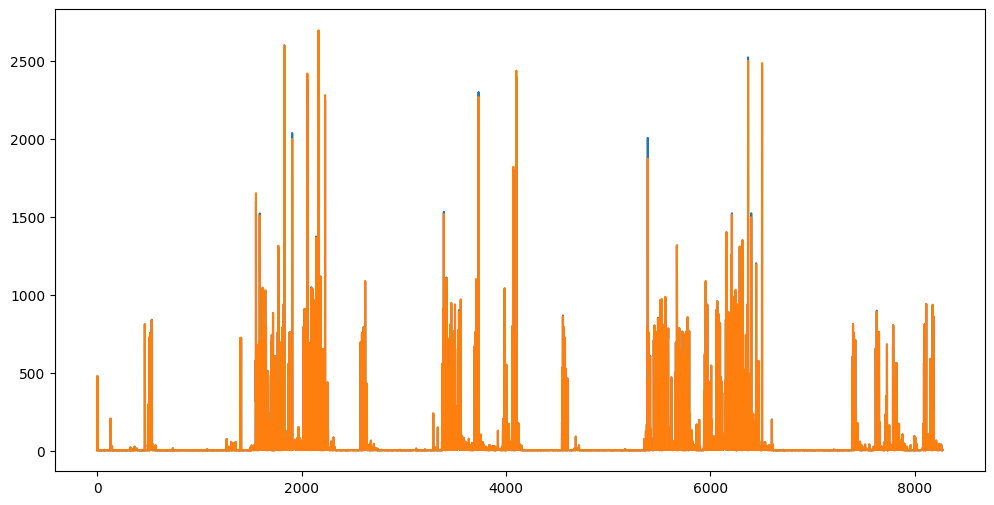

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")


In [24]:
plt.show()

In [25]:
corr = df.corr()[target].abs().sort_values(ascending=False)
top_features = corr.head(20).index
df = df[top_features]

In [26]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=200, learning_rate=0.05)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [27]:
print(df.columns.tolist())

['transmitted_throughput_acamas:-network-device-bond0', 'transmitted_throughput_acamas:-network-device-eno1', 'received_throughput_dedale:-network-device-eno1', 'received_throughput_dedale:-network-device-bond0', 'received_throughput_demophon:-network-device-eno2', 'received_throughput_demophon:-network-device-bond0', 'received_throughput_acamas:-network-device-eno1', 'received_throughput_acamas:-network-device-bond0', 'received_throughput_perse:-network-device-eno1', 'received_throughput_perse:-network-device-bond0', 'transmitted_throughput_perse:-network-device-bond0', 'lag1', 'transmitted_throughput_perse:-network-device-eno1', 'lag2', 'transmitted_throughput_demophon:-network-device-eno2', 'transmitted_throughput_demophon:-network-device-bond0', 'transmitted_throughput_perse:-network-device-eno2', 'lag3', 'transmitted_throughput_phaedra:-network-device-ens3f1', 'received_throughput_perse:-network-device-eno2']


In [28]:
df.columns = df.columns.str.strip()

In [29]:
print(df.columns)

Index(['transmitted_throughput_acamas:-network-device-bond0',
       'transmitted_throughput_acamas:-network-device-eno1',
       'received_throughput_dedale:-network-device-eno1',
       'received_throughput_dedale:-network-device-bond0',
       'received_throughput_demophon:-network-device-eno2',
       'received_throughput_demophon:-network-device-bond0',
       'received_throughput_acamas:-network-device-eno1',
       'received_throughput_acamas:-network-device-bond0',
       'received_throughput_perse:-network-device-eno1',
       'received_throughput_perse:-network-device-bond0',
       'transmitted_throughput_perse:-network-device-bond0', 'lag1',
       'transmitted_throughput_perse:-network-device-eno1', 'lag2',
       'transmitted_throughput_demophon:-network-device-eno2',
       'transmitted_throughput_demophon:-network-device-bond0',
       'transmitted_throughput_perse:-network-device-eno2', 'lag3',
       'transmitted_throughput_phaedra:-network-device-ens3f1',
       'rec

In [30]:
import pandas as pd

target = "transmitted_throughput_acamas:-network-device-bond0"

# features
X = df.drop(columns=[target], errors='ignore')

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.01,  # 1% anomalies
    random_state=42
)

df['anomaly'] = model.fit_predict(X_scaled)

/tmp/ipykernel_10377/859516613.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anomaly'] = model.fit_predict(X_scaled)


In [34]:
anomalies = df[df['anomaly'] == -1]

print("Total anomalies:", len(anomalies))
print(anomalies.head())

Total anomalies: 414
      transmitted_throughput_acamas:-network-device-bond0  \
437                                         2222.261111     
1439                                         772.592222     
1452                                         336.142222     
1615                                         613.014444     
1636                                         567.488889     

      transmitted_throughput_acamas:-network-device-eno1  \
437                                         2222.261111    
1439                                         772.592222    
1452                                         336.142222    
1615                                         613.014444    
1636                                         567.487778    

      received_throughput_dedale:-network-device-eno1  \
437                                       1151.387778   
1439                                         1.341111   
1452                                      1232.440000   
1615                   

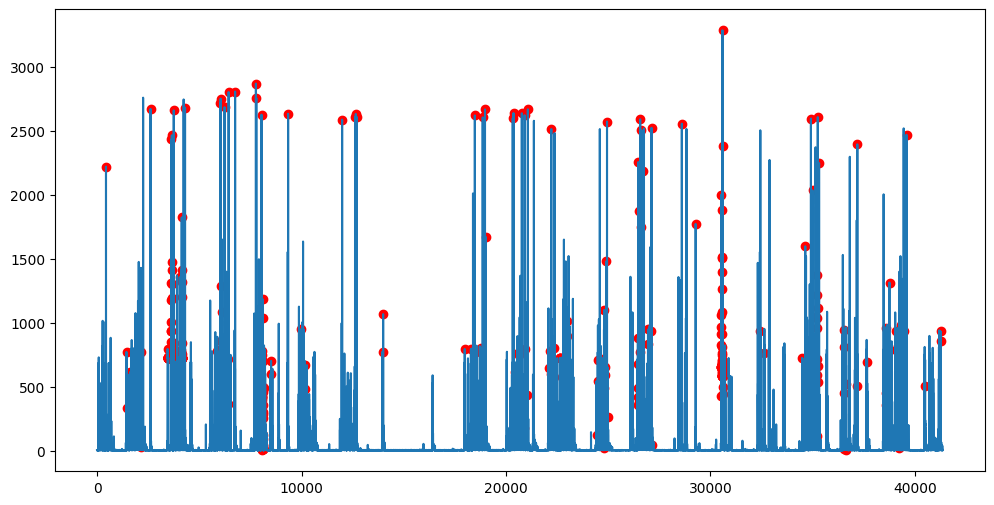

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df[target].values, label="Normal")

plt.scatter(
    anomalies.index,
    anomalies[target],
    color='red',
    label="Anomaly"
)

In [38]:
contamination=0.005   # fewer anomalies
contamination=0.02    # more anomalies

In [39]:
corr = df.corr()[target].abs().sort_values(ascending=False)
top_features = corr.head(15).index

X = df[top_features].drop(columns=[target], errors='ignore')

In [40]:
alerts = df[df['anomaly'] == -1]

for i in alerts.index[:5]:
    print(f"⚠️ ALERT at index {i}")

⚠️ ALERT at index 437
⚠️ ALERT at index 1439
⚠️ ALERT at index 1452
⚠️ ALERT at index 1615
⚠️ ALERT at index 1636


In [41]:
from sklearn.svm import OneClassSVM

model = OneClassSVM(nu=0.01)
df['anomaly_svm'] = model.fit_predict(X_scaled)

/tmp/ipykernel_10377/1274342575.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['anomaly_svm'] = model.fit_predict(X_scaled)


In [42]:
df

,transmitted_throughput_acamas:-network-device-bond0,transmitted_throughput_acamas:-network-device-eno1,received_throughput_dedale:-network-device-eno1,received_throughput_dedale:-network-device-bond0,received_throughput_demophon:-network-device-eno2,received_throughput_demophon:-network-device-bond0,received_throughput_acamas:-network-device-eno1,received_throughput_acamas:-network-device-bond0,received_throughput_perse:-network-device-eno1,received_throughput_perse:-network-device-bond0,...,transmitted_throughput_perse:-network-device-eno1,lag2,transmitted_throughput_demophon:-network-device-eno2,transmitted_throughput_demophon:-network-device-bond0,transmitted_throughput_perse:-network-device-eno2,lag3,transmitted_throughput_phaedra:-network-device-ens3f1,received_throughput_perse:-network-device-eno2,anomaly,anomaly_svm
3,4.244444,4.244444,1.325556,4.804444,0.557778,0.557778,6.250000,6.250000,0.487778,0.654444,...,0.785556,3.972222,0.580000,0.580000,0.130000,4.260000,9.481111,0.166667,1,1
4,4.300000,4.300000,1.842222,5.915556,0.625556,0.625556,5.010000,5.010000,0.373333,0.754444,...,0.972222,3.690000,0.943333,0.943333,0.174444,3.972222,10.502222,0.381111,1,1
5,4.995556,4.995556,1.903333,4.758889,0.452222,0.452222,10.730000,10.730000,0.494444,0.713333,...,0.802222,4.244444,0.612222,0.612222,0.167778,3.690000,7.954444,0.218889,1,1
6,4.078889,4.078889,1.903333,5.898889,0.534444,0.534444,5.067778,5.067778,0.368889,0.598889,...,0.811111,4.300000,0.608889,0.608889,0.146667,4.244444,10.303333,0.230000,1,1
7,3.644444,3.644444,1.403333,4.366667,0.461111,0.461111,4.622222,4.623333,0.486667,0.662222,...,0.773333,4.995556,0.571111,0.571111,0.138889,4.300000,8.950000,0.175556,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41357,4.316667,4.316667,1.843333,6.164444,0.497778,0.497778,6.581111,6.581111,0.416667,0.622222,...,0.828889,5.780000,0.588889,0.588889,0.168889,6.695556,4.376667,0.205556,1,1
41358,8.998889,8.998889,1.523333,4.793333,0.525556,0.525556,8.165556,8.165556,0.411111,0.606667,...,0.828889,4.665556,0.610000,0.610000,0.142222,5.780000,3.496667,0.195556,1,1
41359,5.500000,5.500000,1.632222,5.965556,0.584444,0.584444,11.446667,11.446667,0.496667,0.688889,...,0.774444,4.316667,0.593333,0.593333,0.134444,4.665556,3.608889,0.192222,1,1
41360,4.833333,4.833333,2.046667,5.986667,0.568889,0.568889,6.572222,6.572222,0.411111,0.688889,...,0.820000,8.998889,0.637778,0.637778,0.210000,4.316667,4.198889,0.277778,1,1


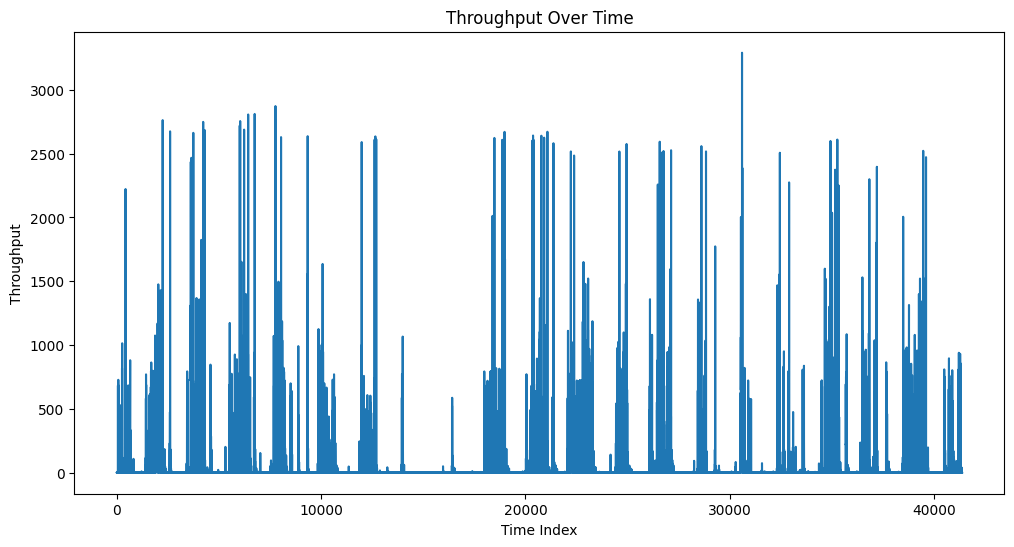

In [43]:
target = "transmitted_throughput_acamas:-network-device-bond0"

plt.figure(figsize=(12,6))
plt.plot(df[target])
plt.title("Throughput Over Time")
plt.xlabel("Time Index")
plt.ylabel("Throughput")
plt.show()

**MULTIPLE DEVICE COMPARISON**

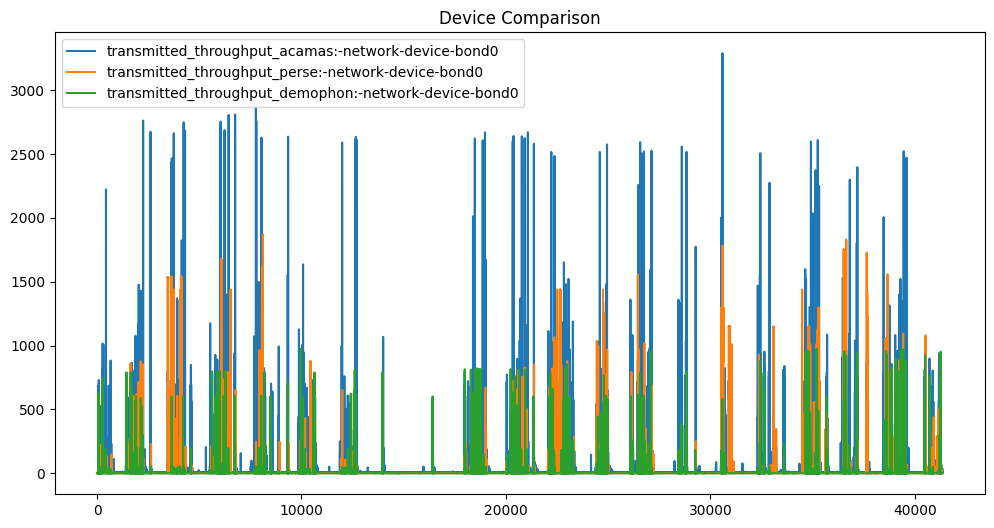

In [44]:
cols = [
    "transmitted_throughput_acamas:-network-device-bond0",
    "transmitted_throughput_perse:-network-device-bond0",
    "transmitted_throughput_demophon:-network-device-bond0"
]

plt.figure(figsize=(12,6))

for col in cols:
    plt.plot(df[col], label=col)

plt.legend()
plt.title("Device Comparison")
plt.show()

**CORRELATION HEATMAP**

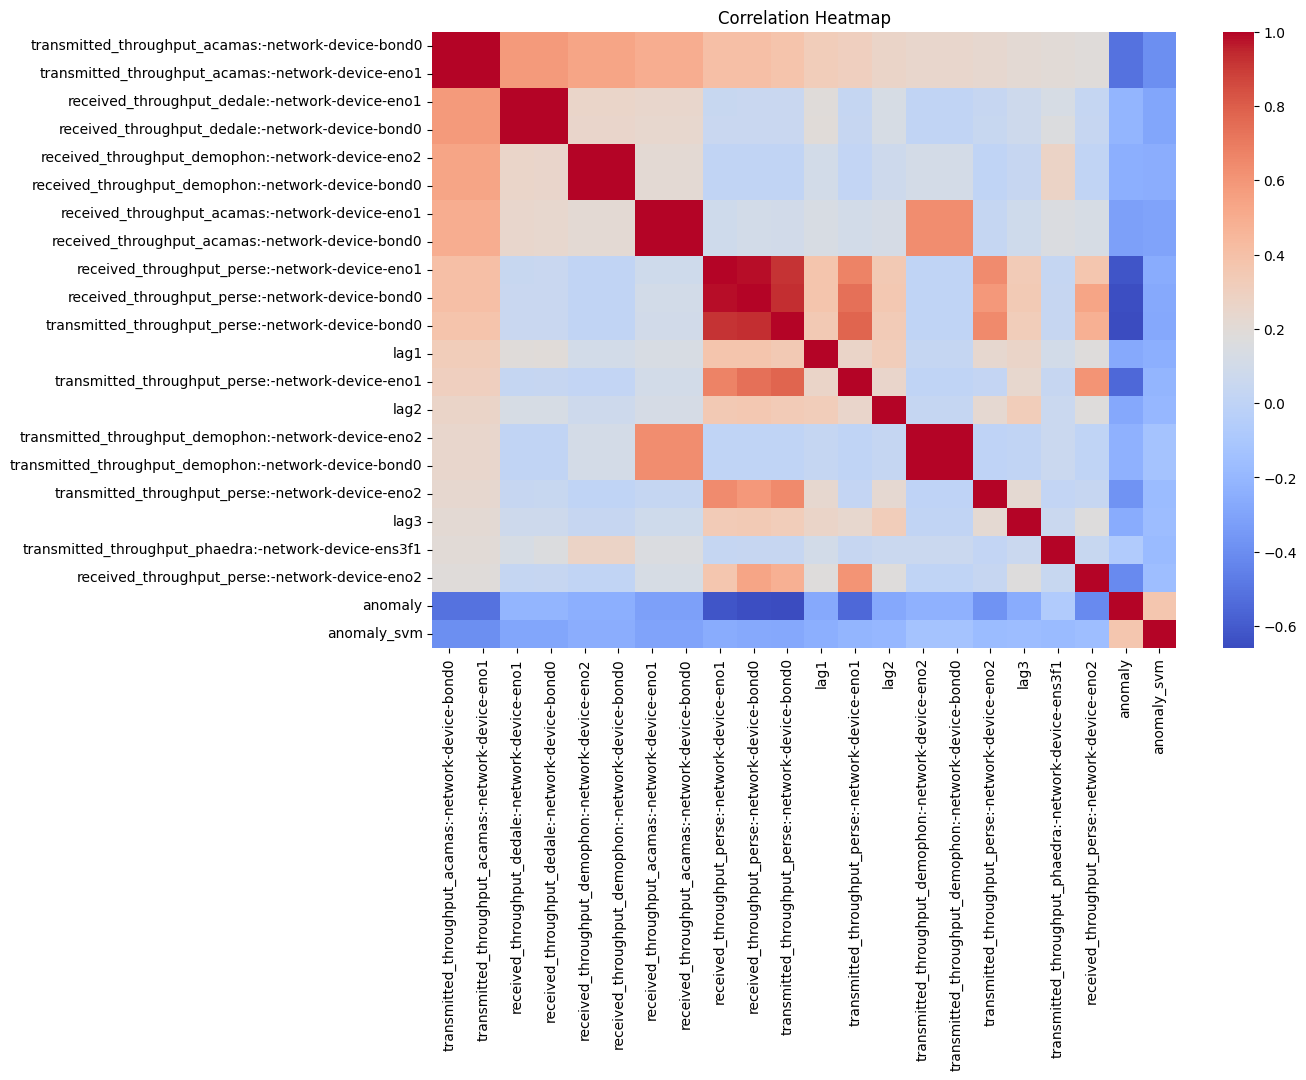

In [46]:
import seaborn as sns
plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

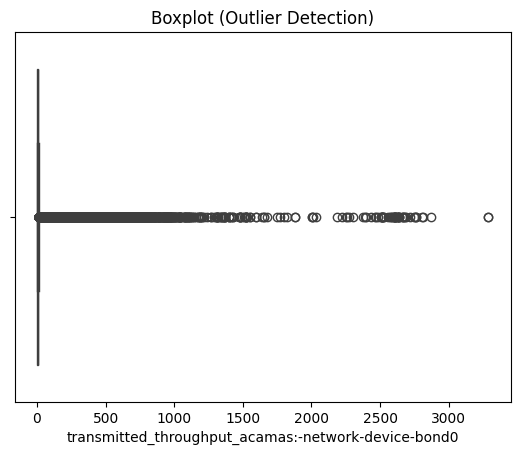

In [47]:
sns.boxplot(x=df[target])
plt.title("Boxplot (Outlier Detection)")
plt.show()

**INTERACTIVE GRAPH**

In [48]:
pip install plotly

In [49]:
import plotly.express as px

fig = px.line(df, y=target, title="Interactive Throughput Graph")
fig.show()